# Análise de Features — Compatibilidade Adotante × Pet

Analisa como cada feature do `compatibility_dataset.csv` se relaciona com o
rótulo `compatibility`, e a importância de cada feature segundo o modelo
treinado (`models/animal-recommender/model.joblib`).

Kernel: selecione **Abrigo Lambeijos ML**.

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd().parent))

from src.config.settings import MODEL_PATH
from src.data.cleaner import clean_compatibility_dataset
from src.data.loader import load_compatibility_dataset
from src.features.feature_builder import build_features_and_target

df = clean_compatibility_dataset(load_compatibility_dataset())
X, y = build_features_and_target(df)
print(f"X: {X.shape}, y: {y.shape}")

X: (750, 20), y: (750,)


## Relação entre features booleanas/numéricas e o rótulo

Taxa de compatibilidade média por valor de cada feature booleana, e
correlação da idade do pet com compatibilidade.

In [2]:
from src.config.settings import BOOLEAN_COLUMNS, NUMERIC_COLUMNS

boolean_rates = pd.DataFrame(
    {col: df.groupby(col)["compatibility"].mean() for col in BOOLEAN_COLUMNS}
)
print("Taxa média de compatibility por valor da feature booleana:")
display(boolean_rates)

print(f"\nCorrelação (Pearson) idade do pet x compatibility: {df['pet_age'].corr(df['compatibility']):.3f}")

Taxa média de compatibility por valor da feature booleana:


,has_yard,has_children,has_other_pets,children_compatibility,dogs_compatibility,cats_compatibility
False,0.556044,0.637209,0.632323,0.420814,0.511475,0.488166
True,0.552542,0.443750,0.403922,0.610586,0.584270,0.609223



Correlação (Pearson) idade do pet x compatibility: -0.014


## Importância de features segundo o modelo treinado

Requer que `python -m src.training.train` já tenha sido rodado (gera
`models/animal-recommender/model.joblib`).

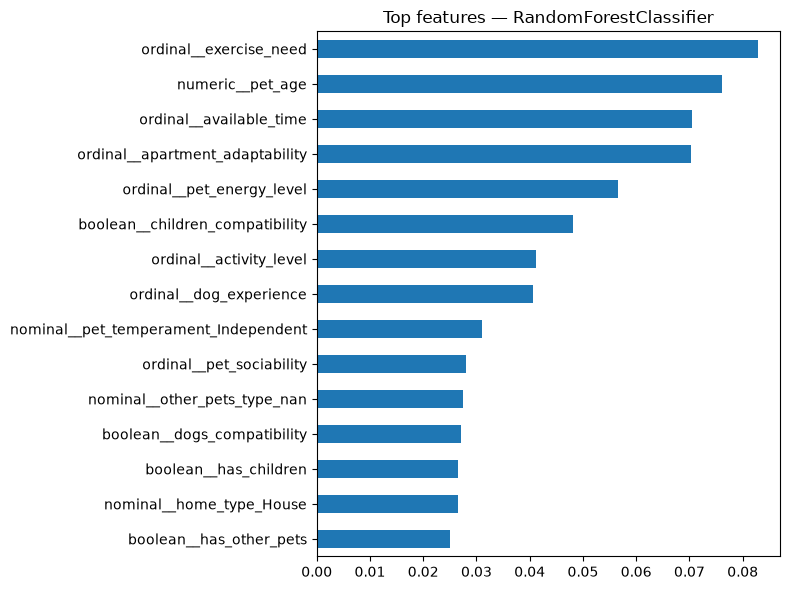

In [3]:
if not MODEL_PATH.exists():
    print(f"Modelo não encontrado em {MODEL_PATH}. Rode `python -m src.training.train` primeiro.")
else:
    pipeline = joblib.load(MODEL_PATH)
    estimator = pipeline.named_steps["estimator"]
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

    if hasattr(estimator, "feature_importances_"):
        importances = pd.Series(estimator.feature_importances_, index=feature_names)
    elif hasattr(estimator, "coef_"):
        importances = pd.Series(np.abs(estimator.coef_[0]), index=feature_names)
    else:
        importances = None

    if importances is not None:
        importances.sort_values(ascending=True).tail(15).plot(
            kind="barh", figsize=(8, 6), title=f"Top features — {type(estimator).__name__}"
        )
        plt.tight_layout()
        plt.show()
    else:
        print(f"{type(estimator).__name__} não expõe importância de features diretamente.")